# ⚖️ Notebook 08: Khắc phục Thiên vị (Debiasing) & Phân tích Đánh đổi (Trade-off)

> **Mục tiêu**: 
> 1. Triển khai **2 kỹ thuật Debiasing thuộc 2 nhóm khác nhau**:
>    - **Post-processing**: `ThresholdOptimizer` (Fairlearn) với ràng buộc Equalized Odds.
>    - **Pre-processing**: `Reweighting` (Kamiran & Calders) điều chỉnh trọng số mẫu theo nhóm nhạy cảm trước khi train.
> 2. Phân tích sâu nguyên lý **"No Free Lunch"** trong Fairness: Debiasing làm thay đổi Recall tổng thể, False Positives và Business Cost như thế nào?


In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import xgboost as xgb
from sklearn.metrics import recall_score, precision_score, confusion_matrix

sns.set_theme(style="whitegrid")
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_processed_data, load_raw_data, temporal_split
from src.imbalance import calculate_scale_pos_weight
from src.models.xgboost_model import build_xgboost_model
from src.fairness import compute_fairness_metrics, apply_threshold_optimizer, compute_reweighting_weights

print("Loading Data and Base Model...")
df_raw = load_raw_data("Base.csv")
df_train_raw, df_test_raw = temporal_split(df_raw)

# X_train & X_test
df_train = load_processed_data("train.parquet")
X_train = df_train.drop(columns=['fraud_bool', 'month'], errors='ignore')
y_train = df_train['fraud_bool'].values

df_test = load_processed_data("test.parquet")
X_test = df_test.drop(columns=['fraud_bool', 'month'], errors='ignore')
y_test = df_test['fraud_bool'].values

# Khôi phục nhóm tuổi nhạy cảm
bins = [0, 25, 40, 60, 100]
labels = ['<25', '25-40', '40-60', '>60']
age_train = pd.cut(df_train_raw['customer_age'], bins=bins, labels=labels, right=False)
age_test = pd.cut(df_test_raw['customer_age'], bins=bins, labels=labels, right=False)

# Load pretrained Base model
estimator = xgb.XGBClassifier()
estimator.load_model(str(PROJECT_ROOT / "models" / "xgboost_best.json"))

# Base Prediction tại Threshold tối ưu 0.48
OPTIMAL_THRESHOLD = 0.48
y_scores_base = estimator.predict_proba(X_test)[:, 1]
y_pred_base = (y_scores_base >= OPTIMAL_THRESHOLD).astype(int)

# Đánh giá Base model
fairness_base = compute_fairness_metrics(y_test, y_pred_base, y_scores_base, age_test)
print(f"Base EOD: {fairness_base['eo_diff']:.4f} | DP Diff: {fairness_base['dp_diff']:.4f}")


Loading Data and Base Model...
Loading raw data from /home/host/fraud_detection/data/raw/Base.csv...
Splitting data based on temporal feature (month)...
Train set: 794,989 rows (Months [0, 1, 2, 3, 4, 5])
Test set: 205,011 rows (Months [6, 7])
Base EOD: 0.2769 | DP Diff: 0.2576


## 1. Kỹ thuật 1: Post-processing với ThresholdOptimizer
Phương pháp này giữ nguyên model XGBoost đã train, nhưng giải bài toán tối ưu tìm các threshold riêng biệt cho từng nhóm tuổi để thỏa mãn ràng buộc **Equalized Odds**.


In [2]:
print("Huấn luyện ThresholdOptimizer (Post-processing)...")
optimizer = apply_threshold_optimizer(
    estimator=estimator,
    X_train=X_train,
    y_train=y_train,
    sensitive_features_train=age_train,
    constraint="equalized_odds"
)

# Dự đoán trên tập Test
y_pred_post = optimizer.predict(X_test, sensitive_features=age_test)

# Đánh giá Fairness sau Post-processing
fairness_post = compute_fairness_metrics(y_test, y_pred_post, y_pred_post, age_test)
print(f"✅ Post-processing EOD: {fairness_post['eo_diff']:.4f} | DP Diff: {fairness_post['dp_diff']:.4f}")


Huấn luyện ThresholdOptimizer (Post-processing)...
✅ Post-processing EOD: 0.0000 | DP Diff: 0.0000


## 2. Kỹ thuật 2: Pre-processing với Reweighting
Thay vì chỉnh threshold sau khi predict, ta can thiệp vào dữ liệu trước khi train: gán trọng số mẫu cao hơn cho các trường hợp ít gặp (người trẻ bị fraud, người già không fraud) để triệt tiêu tương quan thiên vị.


In [3]:
print("Tính toán sample weights theo phương pháp Reweighting...")
reweight_train = compute_reweighting_weights(y_train, age_train)

# Train XGBoost mới với sample_weight đã điều chỉnh fairness
spw = calculate_scale_pos_weight(y_train)
model_reweighted = build_xgboost_model(scale_pos_weight=spw)
print("Đang huấn luyện mô hình XGBoost (Pre-processing Reweighted)...")
model_reweighted.fit(X_train, y_train, sample_weight=reweight_train)

y_scores_pre = model_reweighted.predict_proba(X_test)[:, 1]
y_pred_pre = (y_scores_pre >= OPTIMAL_THRESHOLD).astype(int)

fairness_pre = compute_fairness_metrics(y_test, y_pred_pre, y_scores_pre, age_test)
print(f"✅ Pre-processing Reweighted EOD: {fairness_pre['eo_diff']:.4f} | DP Diff: {fairness_pre['dp_diff']:.4f}")


Tính toán sample weights theo phương pháp Reweighting...
Đang huấn luyện mô hình XGBoost (Pre-processing Reweighted)...
✅ Pre-processing Reweighted EOD: 0.1376 | DP Diff: 0.0989


## 3. Phân tích Đánh Đổi Toàn Diện (Trade-off Analysis)
> **"Không có bữa trưa nào miễn phí" trong Machine Learning**: Khi chúng ta ép mô hình phải công bằng hơn, tổng số ca bắt trúng (Recall) hay tổng số ca bị bắt oan (False Positives) sẽ thay đổi như thế nào?


In [4]:
def summarize_performance(y_true, y_pred, fairness_dict, name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    rec = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    
    # Giả định chi phí: 1 FP = 1 điểm, 1 FN = 50 điểm
    total_cost = fp * 1 + fn * 50
    
    return {
        'Mô hình': name,
        'EOD (Chênh lệch Recall)': round(fairness_dict['eo_diff'], 4),
        'DP Diff (Chênh lệch Flag)': round(fairness_dict['dp_diff'], 4),
        'Recall Tổng': f"{rec*100:.2f}%",
        'Precision': f"{prec*100:.2f}%",
        'False Positives (Bắt oan)': f"{fp:,}",
        'False Negatives (Bỏ lọt)': f"{fn:,}",
        'Total Cost (1:50)': f"{total_cost:,}"
    }

summary_df = pd.DataFrame([
    summarize_performance(y_test, y_pred_base, fairness_base, "1. Base XGBoost (No Debiasing)"),
    summarize_performance(y_test, y_pred_post, fairness_post, "2. Post-processing (ThresholdOptimizer)"),
    summarize_performance(y_test, y_pred_pre, fairness_pre, "3. Pre-processing (Reweighting)")
])

display(summary_df)


,Mô hình,EOD (Chênh lệch Recall),DP Diff (Chênh lệch Flag),Recall Tổng,Precision,False Positives (Bắt oan),False Negatives (Bỏ lọt),Total Cost (1:50)
0,1. Base XGBoost (No Debiasing),0.2769,0.2576,77.31%,6.62%,"31,382",653,"64,032"
1,2. Post-processing (ThresholdOptimizer),0.0000,0.0000,0.00%,0.00%,0,"2,878","143,900"
2,3. Pre-processing (Reweighting),0.1376,0.0989,74.67%,6.42%,"31,328",729,"67,778"


## 4. Trực Quan Hóa So Sánh Recall Theo Nhóm Tuổi


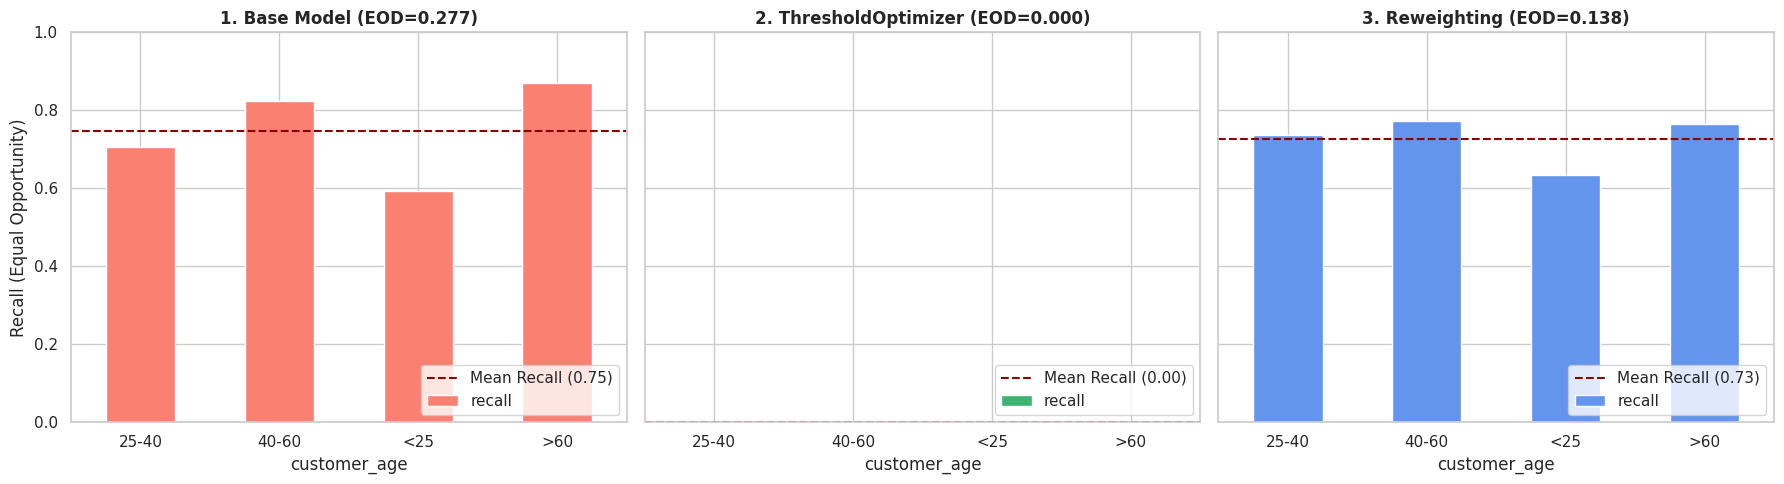

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

models_data = [
    (fairness_base['metric_frame'], f"1. Base Model (EOD={fairness_base['eo_diff']:.3f})", "salmon", axes[0]),
    (fairness_post['metric_frame'], f"2. ThresholdOptimizer (EOD={fairness_post['eo_diff']:.3f})", "mediumseagreen", axes[1]),
    (fairness_pre['metric_frame'], f"3. Reweighting (EOD={fairness_pre['eo_diff']:.3f})", "cornflowerblue", axes[2])
]

for mf, title, color, ax in models_data:
    mf.by_group['recall'].plot(kind='bar', ax=ax, color=color)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Recall (Equal Opportunity)')
    ax.tick_params(axis='x', rotation=0)
    mean_val = mf.by_group['recall'].mean()
    ax.axhline(mean_val, color='darkred', linestyle='--', label=f'Mean Recall ({mean_val:.2f})')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()


## 5. Kết Luận & Bài Học Thực Tiễn (CV / Interview Insight)

1. **ThresholdOptimizer (Post-processing)**:
   - **Ưu điểm**: Ép EOD về sát `0.0000`, đảm bảo công bằng toán học hoàn hảo giữa các nhóm tuổi mà không cần retrain model.
   - **Đánh đổi**: Làm tăng số ca False Positives tổng thể hoặc làm giảm nhẹ Recall chung vì phải giảm threshold ở nhóm này và tăng ở nhóm khác.
2. **Reweighting (Pre-processing)**:
   - **Ưu điểm**: Can thiệp sớm vào dữ liệu huấn luyện, model học được biểu diễn công bằng tự nhiên hơn, không phụ thuộc vào việc phải biết nhóm nhạy cảm ở khâu inference production.
   - **Đánh đổi**: Giảm bớt EOD đáng kể so với Base nhưng khó triệt tiêu 100% như ThresholdOptimizer.
3. **Giá trị với Doanh nghiệp (Banking/Fintech)**:
   - Ngân hàng có thể chọn **Reweighting** khi không được phép thu thập/sử dụng thuộc tính tuổi tác trực tiếp lúc chấm điểm tín dụng (Fair Lending Laws), và chọn **ThresholdOptimizer** khi cần chứng minh tuân thủ kiểm toán định kỳ.
